<a href="https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch-2E/blob/main/Chapter11/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# %pip install -q torch_snippets
from torch_snippets import *
from torch_snippets.torch_loader import Report

import torch
import torch.nn as nn
from torch.utils.data import random_split, Dataset, DataLoader
import matplotlib.pyplot as plt
from torch import optim
import torch.nn.functional as F
from torchvision.utils import make_grid

from torchvision import datasets
from torchvision import transforms
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:

train_dataset = datasets.MNIST(root='../data/MNIST', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='../data/MNIST', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

In [3]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        self.d1 = nn.Linear(x_dim, h_dim1)
        self.d2 = nn.Linear(h_dim1, h_dim2)
        self.d31 = nn.Linear(h_dim2, z_dim)
        self.d32 = nn.Linear(h_dim2, z_dim)
        self.d4 = nn.Linear(z_dim, h_dim2)
        self.d5 = nn.Linear(h_dim2, h_dim1)
        self.d6 = nn.Linear(h_dim1, x_dim)
    def encoder(self, x):
        h = F.relu(self.d1(x))
        h = F.relu(self.d2(h))
        return self.d31(h), self.d32(h)
    def sampling(self, mean, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean)
    def decoder(self, z):
        h = F.relu(self.d4(z))
        h = F.relu(self.d5(h))
        return F.sigmoid(self.d6(h))
    def forward(self, x):
        mean, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mean, log_var)
        return self.decoder(z), mean, log_var


In [4]:
def train_batch(data, model, optimizer, loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()

@torch.no_grad()
def validate_batch(data, model, loss_function):
    model.eval()
    data = data.to(device)
    recon, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon, data, mean, log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [5]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

In [6]:
vae = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=50).to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

EPOCH: 1.000  val_kld: 426.584  train_loss: 2951.788  val_mean: -0.003  train_recon: 2702.391  train_mean: 0.000  val_log_var: -0.249  train_log_var: -0.151  val_loss: 2394.799  val_recon: 1968.215  train_kld: 249.396  (14.85s - 133.67s remaining)


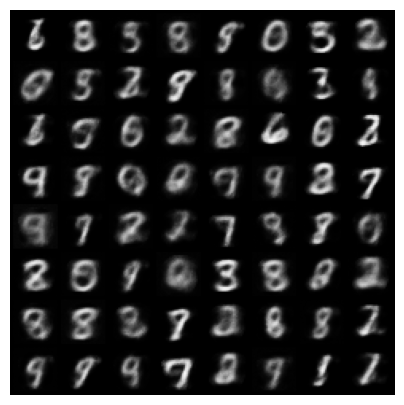

EPOCH: 2.000  val_kld: 513.067  train_loss: 2217.896  val_mean: 0.000  train_recon: 1730.305  train_mean: 0.002  val_log_var: -0.309  train_log_var: -0.296  val_loss: 2103.309  val_recon: 1590.242  train_kld: 487.590  (29.54s - 118.15s remaining)


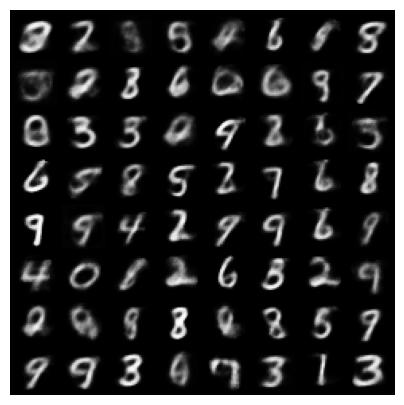

EPOCH: 3.000  val_kld: 578.722  train_loss: 2073.029  val_mean: 0.004  train_recon: 1531.192  train_mean: 0.001  val_log_var: -0.360  train_log_var: -0.334  val_loss: 2020.829  val_recon: 1442.107  train_kld: 541.837  (44.00s - 102.66s remaining)


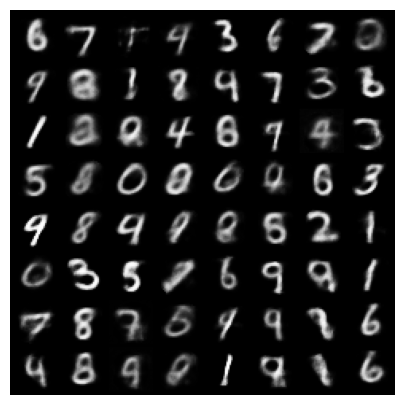

EPOCH: 4.000  val_kld: 574.361  train_loss: 1999.944  val_mean: 0.007  train_recon: 1430.984  train_mean: 0.001  val_log_var: -0.355  train_log_var: -0.351  val_loss: 1962.444  val_recon: 1388.083  train_kld: 568.960  (58.69s - 88.03s remaining)


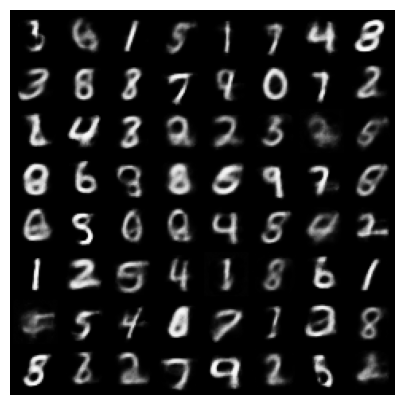

EPOCH: 5.000  val_kld: 597.976  train_loss: 1959.841  val_mean: 0.006  train_recon: 1373.184  train_mean: 0.001  val_log_var: -0.368  train_log_var: -0.363  val_loss: 1927.701  val_recon: 1329.725  train_kld: 586.658  (73.23s - 73.23s remaining)


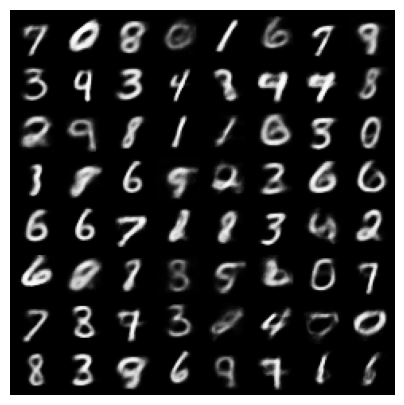

EPOCH: 6.000  val_kld: 597.589  train_loss: 1930.532  val_mean: -0.001  train_recon: 1332.737  train_mean: 0.001  val_log_var: -0.373  train_log_var: -0.371  val_loss: 1910.567  val_recon: 1312.978  train_kld: 597.795  (87.79s - 58.53s remaining)


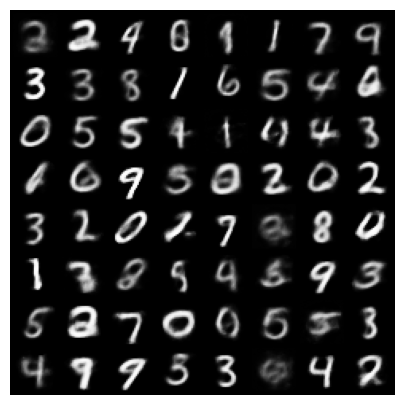

EPOCH: 7.000  val_kld: 611.015  train_loss: 1907.785  val_mean: 0.002  train_recon: 1303.033  train_mean: 0.001  val_log_var: -0.387  train_log_var: -0.376  val_loss: 1882.866  val_recon: 1271.851  train_kld: 604.751  (102.38s - 43.88s remaining)


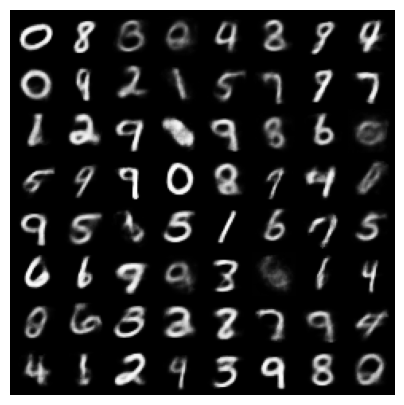

EPOCH: 8.000  val_kld: 590.722  train_loss: 1889.201  val_mean: 0.003  train_recon: 1276.484  train_mean: 0.001  val_log_var: -0.371  train_log_var: -0.381  val_loss: 1867.031  val_recon: 1276.308  train_kld: 612.717  (116.97s - 29.24s remaining)


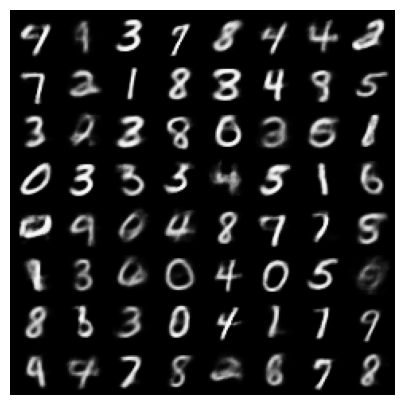

EPOCH: 9.000  val_kld: 616.670  train_loss: 1875.904  val_mean: 0.004  train_recon: 1255.532  train_mean: 0.001  val_log_var: -0.389  train_log_var: -0.386  val_loss: 1857.930  val_recon: 1241.259  train_kld: 620.372  (131.69s - 14.63s remaining)


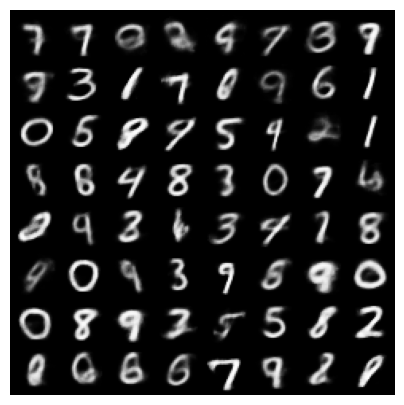

EPOCH: 10.000  val_kld: 639.645  train_loss: 1863.466  val_mean: -0.002  train_recon: 1239.105  train_mean: 0.001  val_log_var: -0.396  train_log_var: -0.389  val_loss: 1845.718  val_recon: 1206.073  train_kld: 624.361  (146.22s - 0.00s remaining)


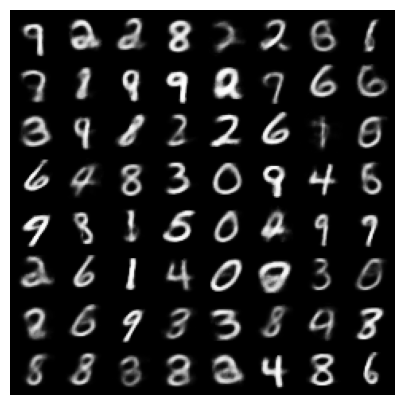

In [7]:
n_epochs = 10
log = Report(n_epochs)

for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')
        
    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')
        
    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 50).to(device)
        sample = vae.decoder(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)

100%|██████████| 111/111 [00:00<00:00, 508.81it/s]


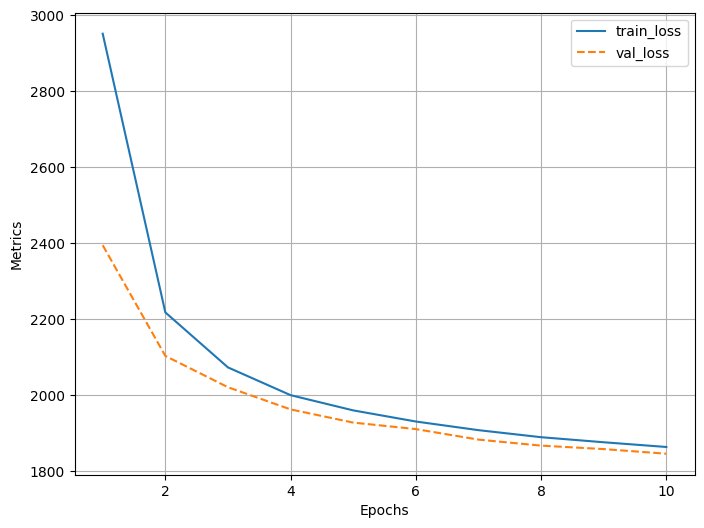

In [8]:
log.plot_epochs(['train_loss','val_loss'])